## Exercise - Detect and Interpret Wind Speed Outliers

- Use `.describe()` to inspect the wind speed (`Ff`) column.
- Create two plots:

1. a histogram of `Ff`
2. a boxplot of `Ff`

Use the plots to see whether there are unusually low or high wind speed values.

Then detect possible outliers using two methods:

1. **IQR method**
   - calculate Q1
   - calculate Q3
   - calculate IQR
   - calculate the lower bound
   - calculate the upper bound
   - count how many values are outside these bounds

2. **Z-score method**
   - calculate Z-scores for `Ff`
   - count how many values have `|Z| > 3`

---

### Questions

Answer the following questions based on your calculations and plots:

1. What were the minimum and maximum values of `Ff`?
2. How many outliers were detected using the IQR method?
3. How many outliers were detected using the Z-score method?
4. Do the high wind speed values look like possible real weather events or likely data errors?
5. Would you remove these values, keep them, or investigate them further? Explain your choice.

### Answers

2. The minimum wind speed value was **0.0 m/s** and the maximum wind speed value was **10.0 m/s**.
3. The IQR method detected **87 outliers**.
4. The Z-score method also detected **87 outliers**.
6. The high wind speed values look like possible real weather events rather than obvious data errors. A maximum wind speed of **10.0 m/s** is high compared to the typical values in the dataset, but it is still realistic for windy or stormy weather in Estonia.
7. I would not remove them automatically. Since high wind speeds can be real weather events, they may contain useful information for energy analysis. I would keep them or investigate the corresponding timestamps further before deciding whether they are errors.

In [1]:
# Imports

import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [5]:
weather = pd.read_csv('../data/weather_2022.csv',  delimiter=';', decimal='.', index_col = False)

weather['timestamp'] = pd.to_datetime(weather['Local time in Tallinn (airport)'], dayfirst=True)
weather.set_index('timestamp', inplace=True)
weather.drop(columns=['Local time in Tallinn (airport)'], inplace=True)

In [10]:
weather["Ff"].describe()

count    8721.000000
mean        3.014219
std         1.577299
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: Ff, dtype: float64

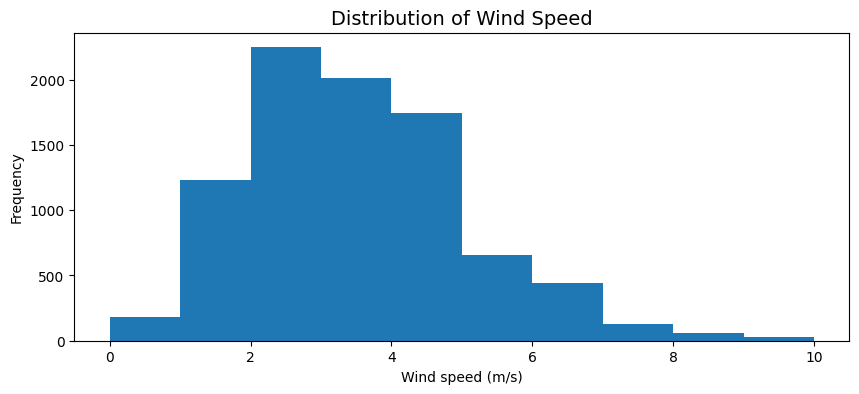

In [14]:
plt.figure(figsize=(10, 4))
plt.hist(weather["Ff"].dropna(), bins=10)
plt.title("Distribution of Wind Speed", fontsize=14)
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Frequency")
plt.show()

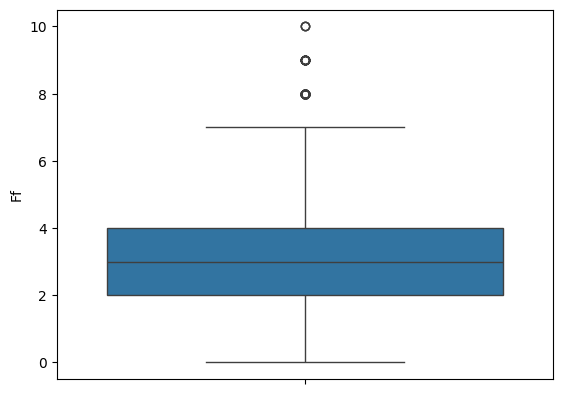

In [15]:
sns.boxplot(weather["Ff"]);

In [16]:
Q1 = weather["Ff"].quantile(0.25)
Q3 = weather["Ff"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = weather[
    (weather["Ff"] < lower_bound) |
    (weather["Ff"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of IQR outliers:", len(iqr_outliers))

iqr_outliers[["Ff"]].head()

Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower bound: -1.0
Upper bound: 7.0
Number of IQR outliers: 87


,Ff
timestamp,
2022-12-12 20:00:00,8.0
2022-12-12 19:00:00,8.0
2022-12-12 18:00:00,8.0
2022-12-12 17:00:00,8.0
2022-12-12 16:00:00,9.0


In [17]:
mean = weather["Ff"].mean()
std = weather["Ff"].std()

z_scores = (weather["Ff"] - mean) / std

z_outliers = weather[abs(z_scores) > 3]

print("Mean:", mean)
print("Standard deviation:", std)
print("Number of Z-score outliers:", len(z_outliers))

z_outliers[["Ff"]].head()

Mean: 3.0142185529182433
Standard deviation: 1.5772987047683793
Number of Z-score outliers: 87


,Ff
timestamp,
2022-12-12 20:00:00,8.0
2022-12-12 19:00:00,8.0
2022-12-12 18:00:00,8.0
2022-12-12 17:00:00,8.0
2022-12-12 16:00:00,9.0
